# Isolation Forest for Satellite Telemetry Anomaly Detection

## NASA SMAP/MSL Dataset — Per-channel Evaluation

This notebook implements Isolation Forest (IF) for unsupervised anomaly detection on the
NASA SMAP (Soil Moisture Active Passive) and MSL (Mars Science Laboratory) telemetry dataset.

**Protocol:**
- Train on NASA-provided `train/` split (normal operation data, no anomalies)
- Evaluate on NASA-provided `test/` split (contains labelled anomaly sequences)
- Per-channel evaluation with robust rolling features + adaptive threshold

In [1]:
import numpy as np
import pandas as pd
import os, ast, json, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report)

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 42
np.random.seed(SEED)

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data')
if not os.path.exists(os.path.join(DATA_DIR, 'labeled_anomalies.csv')):
    DATA_DIR = 'data'
EVAL_CHANNELS = ['P-1', 'S-1', 'E-1', 'E-2', 'F-1', 'G-1', 'D-1', 'M-5']
SCORE_THRESHOLD_PCT = 3
CONTEXT_WINDOW = 1500

---
## 1. Data Loading

In [2]:
labels_df = pd.read_csv(os.path.join(DATA_DIR, 'labeled_anomalies.csv'))
print(f'Labels file: {len(labels_df)} channels')
labels_df.head()

Labels file: 82 channels


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [3]:
available_channels = []
for ch in EVAL_CHANNELS:
    has_train = os.path.exists(os.path.join(DATA_DIR, 'train', f'{ch}.npy'))
    has_test  = os.path.exists(os.path.join(DATA_DIR, 'test',  f'{ch}.npy'))
    has_label = ch in labels_df['chan_id'].values
    if has_train and has_test and has_label:
        train_arr = np.load(os.path.join(DATA_DIR, 'train', f'{ch}.npy'))
        test_arr  = np.load(os.path.join(DATA_DIR, 'test',  f'{ch}.npy'))
        available_channels.append({
            'channel': ch,
            'spacecraft': labels_df[labels_df['chan_id']==ch].iloc[0]['spacecraft'],
            'train_shape': train_arr.shape,
            'test_shape':  test_arr.shape,
        })

ch_info = pd.DataFrame(available_channels)
print(f'Available channels with train+test: {len(ch_info)}')
ch_info

Available channels with train+test: 8


,channel,spacecraft,train_shape,test_shape
0,P-1,SMAP,"(2872, 25)","(8505, 25)"
1,S-1,SMAP,"(2818, 25)","(7331, 25)"
2,E-1,SMAP,"(2880, 25)","(8516, 25)"
3,E-2,SMAP,"(2880, 25)","(8532, 25)"
4,F-1,SMAP,"(2869, 25)","(8584, 25)"
5,G-1,SMAP,"(2820, 25)","(8469, 25)"
6,D-1,SMAP,"(2849, 25)","(8509, 25)"
7,M-5,MSL,"(2032, 55)","(2303, 55)"


---
## 2. Label Parsing

The `labeled_anomalies.csv` stores anomaly intervals as Python lists of `[start, end]` index pairs.

P-1: 8505 points, 751 anomalous (8.8%)


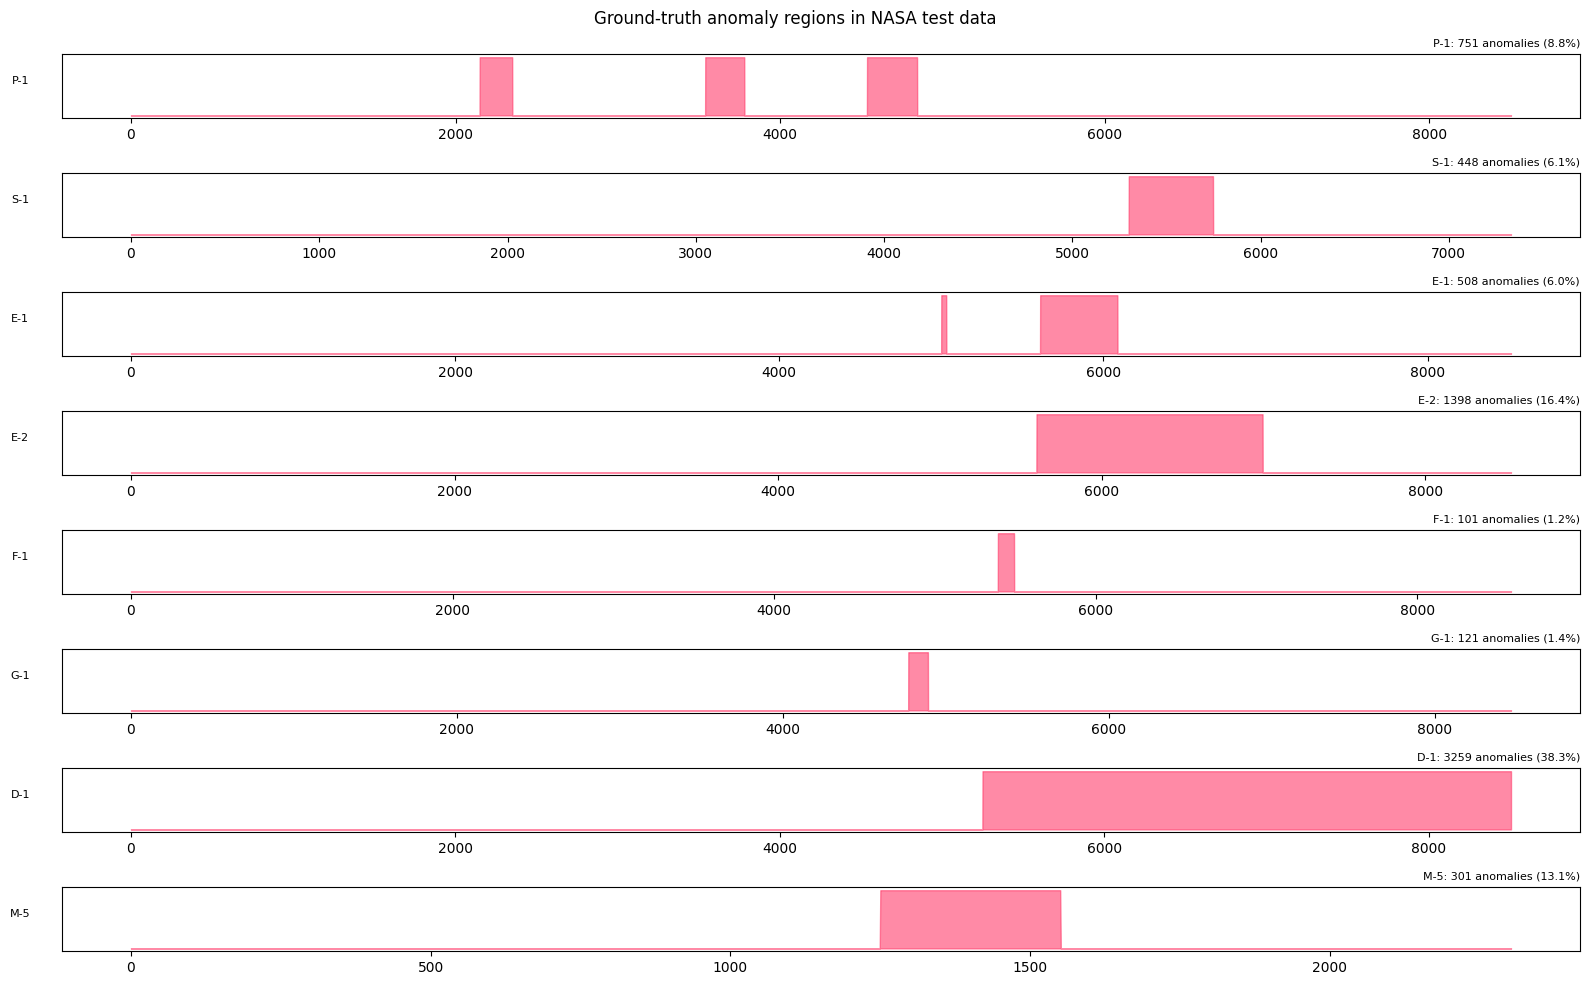

In [4]:
def parse_labels(labels_df, channel_id, T):
    """Convert anomaly_sequences from CSV into binary array of length T."""
    arr = np.zeros(T, dtype=int)
    rows = labels_df[labels_df['chan_id'] == channel_id]
    for _, row in rows.iterrows():
        try:
            seqs = ast.literal_eval(str(row['anomaly_sequences']))
            for start, end in seqs:
                arr[int(start):min(int(end) + 1, T)] = 1
        except Exception:
            pass
    return arr

# Example: P-1 labels
p1_labels = parse_labels(labels_df, 'P-1', 8505)
print(f'P-1: {len(p1_labels)} points, {p1_labels.sum()} anomalous ({p1_labels.mean()*100:.1f}%)')

# Visualize anomaly locations for each channel
fig, axes = plt.subplots(len(EVAL_CHANNELS), 1, figsize=(16, 10), sharex=False)
for i, ch in enumerate(EVAL_CHANNELS):
    test_arr = np.load(os.path.join(DATA_DIR, 'test', f'{ch}.npy'))
    if test_arr.ndim == 1: test_arr = test_arr.reshape(-1, 1)
    T = test_arr.shape[0]
    labs = parse_labels(labels_df, ch, T)
    axes[i].fill_between(range(T), 0, labs, alpha=0.6, color='#ff3d6b')
    axes[i].set_ylabel(ch, fontsize=8, rotation=0, labelpad=30)
    axes[i].set_yticks([])
    axes[i].set_title(f'{ch}: {labs.sum()} anomalies ({labs.mean()*100:.1f}%)',
                      fontsize=8, loc='right')
plt.suptitle('Ground-truth anomaly regions in NASA test data', fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Feature Engineering — Robust Rolling Features

Isolation Forest is a point-wise anomaly detector. On time-series data, anomalies are
**contextual** (a value is anomalous only relative to its local context). We bridge this gap
with robust rolling statistics:

- **Rolling median** at 3 time-scales (50, 300, 1500) — captures trend without contamination by outliers
- **Robust z-score** = |value - rolling_median| / (1.4826 * rolling_MAD) — normalized deviation
- **Alarm count** — number of recent z-score excursions above threshold
- **Absolute diff** — point-to-point change magnitude

In [5]:
def make_channel_features(arr_2d):
    """Build robust rolling features from a 2D numpy array (T x D)."""
    T, D = arr_2d.shape
    df = pd.DataFrame()
    df['val'] = arr_2d[:, 0]

    for w_name, w_size in [('s', 50), ('m', 300), ('l', 1500)]:
        minp = max(1, w_size // 4)
        rmed = df['val'].rolling(window=w_size, min_periods=minp).median()
        resid = (df['val'] - rmed).abs()
        mad = resid.rolling(window=w_size, min_periods=minp).median()
        rzscore = (resid / (1.4826 * mad.clip(lower=1e-8))).clip(upper=30).fillna(0)
        df[f'rmed_{w_name}'] = rmed
        df[f'resid_{w_name}'] = resid
        df[f'rzscore_{w_name}'] = rzscore
        alarm = (rzscore > 2.5).astype(int).rolling(window=30, min_periods=1).sum()
        df[f'alarm_{w_name}'] = alarm

    df['diff'] = df['val'].diff().fillna(0).abs()
    return df

# Demo on P-1
p1_arr = np.load(os.path.join(DATA_DIR, 'test', 'P-1.npy'))
p1_feats = make_channel_features(p1_arr)
print(f'Feature matrix shape: {p1_feats.shape}')
p1_feats.head(10)

Feature matrix shape: (8505, 14)


,val,rmed_s,resid_s,rzscore_s,alarm_s,rmed_m,resid_m,rzscore_m,alarm_m,rmed_l,resid_l,rzscore_l,alarm_l,diff
0,-0.695162,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.000000
1,-0.685704,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.009458
2,-0.725719,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.040015
3,-0.761368,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.035649
4,-0.745362,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.016006
5,-0.735904,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.009458
6,-0.696617,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.039287
7,-0.839942,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.143325
8,-0.031648,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.808294
9,0.009822,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,0.041470


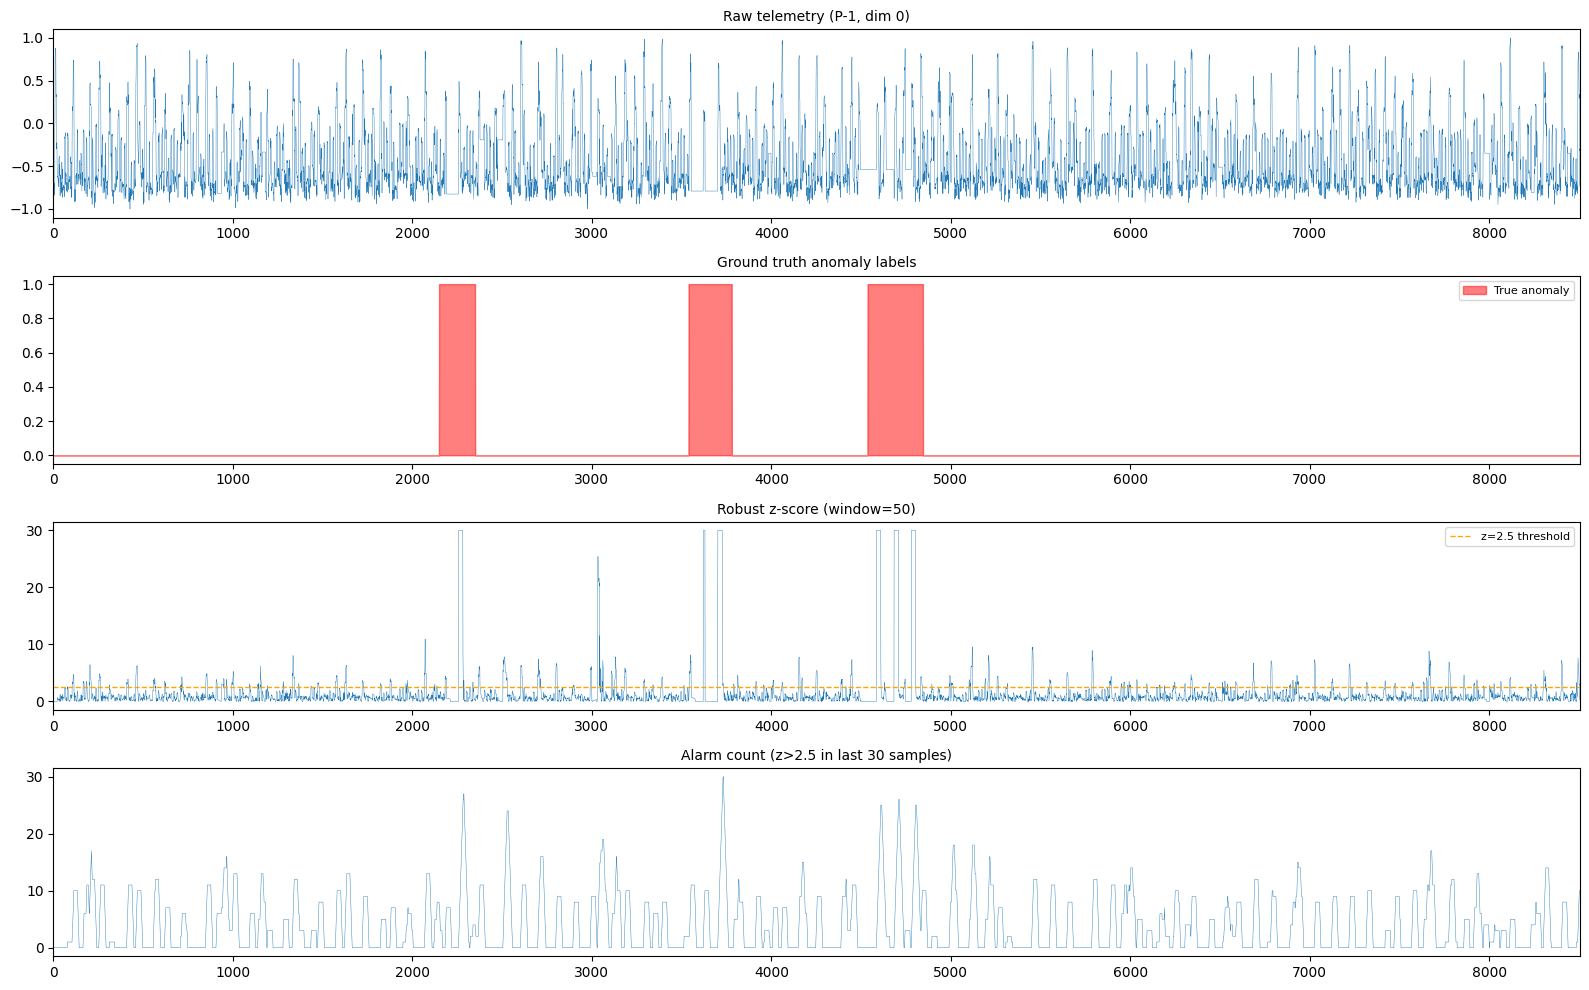

Robust z-score stats:
  Normal: mean=1.12, 95p=3.85
  Anomaly: mean=5.89, 95p=30.00


In [6]:
# Visualize: why raw values fail, but robust z-score works
p1_labels = parse_labels(labels_df, 'P-1', p1_arr.shape[0])
normal_mask = p1_labels == 0
anom_mask  = p1_labels == 1

fig, axes = plt.subplots(4, 1, figsize=(16, 10))
axes[0].plot(p1_arr[:, 0], lw=0.3)
axes[0].set_title('Raw telemetry (P-1, dim 0)', fontsize=10)

axes[1].fill_between(range(len(p1_labels)), 0, p1_labels, alpha=0.5, color='red', label='True anomaly')
axes[1].set_title('Ground truth anomaly labels', fontsize=10)
axes[1].legend(fontsize=8)

axes[2].plot(p1_feats['rzscore_s'].values, lw=0.3)
axes[2].axhline(2.5, color='orange', ls='--', lw=1, label='z=2.5 threshold')
axes[2].set_title('Robust z-score (window=50)', fontsize=10)
axes[2].legend(fontsize=8)

axes[3].plot(p1_feats['alarm_s'].values, lw=0.3)
axes[3].set_title('Alarm count (z>2.5 in last 30 samples)', fontsize=10)

for ax in axes:
    ax.set_xlim(0, len(p1_labels))
plt.tight_layout()
plt.show()

# Separability check
rz_normal = p1_feats['rzscore_s'].values[normal_mask]
rz_anom   = p1_feats['rzscore_s'].values[anom_mask]
print('Robust z-score stats:')
print(f'  Normal: mean={rz_normal.mean():.2f}, 95p={np.percentile(rz_normal, 95):.2f}')
print(f'  Anomaly: mean={rz_anom.mean():.2f}, 95p={np.percentile(rz_anom, 95):.2f}')

---
## 4. Per-Channel Pipeline

**Key design decisions:**
1. **Train on NASA train/ split** (normal data) — avoids contaminating the model with anomalies
2. **Context prefix** from tail of train data — ensures rolling features are initialized at test start
3. **Adaptive threshold** from train score distribution (3rd percentile) — not a fixed contamination rate
4. **StandardScaler fit on train features only** — prevents data leakage

In [7]:
def run_channel(ch, labels_df, data_dir=DATA_DIR, seed=SEED,
                threshold_pct=SCORE_THRESHOLD_PCT,
                context_window=CONTEXT_WINDOW):
    """Run IF on a single channel: train on clean data, evaluate on test."""
    train_arr = np.load(os.path.join(data_dir, 'train', f'{ch}.npy'))
    test_arr  = np.load(os.path.join(data_dir, 'test',  f'{ch}.npy'))
    if train_arr.ndim == 1: train_arr = train_arr.reshape(-1, 1)
    if test_arr.ndim == 1:  test_arr  = test_arr.reshape(-1, 1)

    T_test = test_arr.shape[0]
    label_arr = parse_labels(labels_df, ch, T_test)

    # Context prefix from train tail -> rolling features start warm
    tail = train_arr[-context_window:]
    combined = np.vstack([tail, test_arr])

    df_train = make_channel_features(train_arr)
    df_comb  = make_channel_features(combined)
    df_test  = df_comb.iloc[context_window:].reset_index(drop=True)

    df_test['true_anomaly'] = label_arr
    df_test['channel_id']  = ch

    feature_cols = list(df_train.columns)

    # Preprocessing: fit scaler on train only
    X_tr = df_train[feature_cols].fillna(0).values
    X_te = df_test[feature_cols].fillna(0).values
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # Train IF with minimal contamination (we use custom threshold)
    model = IsolationForest(
        n_estimators=300, contamination=0.01, max_features=1.0,
        random_state=seed, n_jobs=-1,
    )
    model.fit(X_tr_s)

    # Score-based threshold from train distribution
    train_scores = model.decision_function(X_tr_s)
    test_scores  = model.decision_function(X_te_s)
    threshold = np.percentile(train_scores, threshold_pct)

    y_pred = (test_scores < threshold).astype(int)
    y_true = label_arr

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0

    return {
        'channel': ch, 'spacecraft': labels_df[labels_df['chan_id']==ch].iloc[0]['spacecraft'],
        'precision': prec, 'recall': rec, 'f1': f1,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'test_points': T_test, 'n_anomalies': int(label_arr.sum()),
        'anomaly_rate': label_arr.mean(),
        'test_scores': test_scores, 'y_pred': y_pred, 'y_true': y_true,
        'threshold': threshold,
        'df_test': df_test, 'feature_cols': feature_cols,
        'model': model, 'scaler': scaler,
    }

print('Single-channel pipeline ready.')

Single-channel pipeline ready.


In [8]:
%%time
results = {}
for ch in EVAL_CHANNELS:
    print(f'Processing {ch}...')
    results[ch] = run_channel(ch, labels_df)
print('\nAll channels done.')

Processing P-1...


Processing S-1...


Processing E-1...


Processing E-2...


Processing F-1...


Processing G-1...


Processing D-1...


Processing M-5...



All channels done.
CPU times: total: 3.97 s
Wall time: 3.92 s


---
## 5. Results — Per-Channel Metrics

In [9]:
rows = []
for ch, r in results.items():
    rows.append({
        'Channel': ch, 'Spacecraft': r['spacecraft'],
        'Test pts': r['test_points'], 'Anomalies': r['n_anomalies'],
        'Anomaly %': f"{r['anomaly_rate']*100:.1f}%",
        'Precision': f"{r['precision']:.1%}", 'Recall': f"{r['recall']:.1%}",
        'F1': f"{r['f1']:.1%}",
        'TP': r['tp'], 'FP': r['fp'], 'FN': r['fn'], 'TN': r['tn'],
    })
df_results = pd.DataFrame(rows)
df_results

,Channel,Spacecraft,Test pts,Anomalies,Anomaly %,Precision,Recall,F1,TP,FP,FN,TN
0,P-1,SMAP,8505,751,8.8%,30.7%,20.0%,24.2%,150,339,601,7415
1,S-1,SMAP,7331,448,6.1%,72.2%,46.9%,56.8%,210,81,238,6802
2,E-1,SMAP,8516,508,6.0%,73.4%,41.9%,53.4%,213,77,295,7931
3,E-2,SMAP,8532,1398,16.4%,67.7%,17.8%,28.2%,249,119,1149,7015
4,F-1,SMAP,8584,101,1.2%,1.0%,2.0%,1.3%,2,195,99,8288
5,G-1,SMAP,8469,121,1.4%,2.5%,5.8%,3.5%,7,273,114,8075
6,D-1,SMAP,8509,3259,38.3%,89.5%,92.3%,90.8%,3007,354,252,4896
7,M-5,MSL,2303,301,13.1%,37.5%,5.0%,8.8%,15,25,286,1977


In [10]:
# Aggregate metrics
tp_all = sum(r['tp'] for r in results.values())
fp_all = sum(r['fp'] for r in results.values())
fn_all = sum(r['fn'] for r in results.values())
tn_all = sum(r['tn'] for r in results.values())

micro_p = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0
micro_r = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0
macro_f1 = np.mean([r['f1'] for r in results.values()])

print('='*60)
print('  ISOLATION FOREST -- NASA SMAP/MSL RESULTS')
print('='*60)
print(f'  Channels      : {len(results)}')
print(f'  Micro-avg     : P={micro_p:.1%}  R={micro_r:.1%}  F1={micro_f1:.1%}')
print(f'  Macro-avg F1  : {macro_f1:.1%}')
print(f'  Confusion Matrix (micro):')
print(f'    TN={tn_all:>6}  FP={fp_all:>6}')
print(f'    FN={fn_all:>6}  TP={tp_all:>6}')
print('='*60)

  ISOLATION FOREST -- NASA SMAP/MSL RESULTS
  Channels      : 8
  Micro-avg     : P=72.5%  R=55.9%  F1=63.1%
  Macro-avg F1  : 33.4%
  Confusion Matrix (micro):
    TN= 52399  FP=  1463
    FN=  3034  TP=  3853


---
## 6. Visualization

In [11]:
DARK_BG  = '#0a0e1a'
PANEL_BG = '#0f1628'
ACCENT   = '#00d4ff'
ANOMALY  = '#ff3d6b'
NORMAL   = '#1a8cff'
GRID_CLR = '#1e2a4a'
TEXT_CLR = '#c8d8f0'

def style_ax(ax):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT_CLR, labelsize=7)
    ax.xaxis.label.set_color(TEXT_CLR)
    ax.yaxis.label.set_color(TEXT_CLR)
    ax.title.set_color(ACCENT)
    for spine in ax.spines.values():
        spine.set_color(GRID_CLR)
    ax.grid(True, color=GRID_CLR, alpha=0.3)

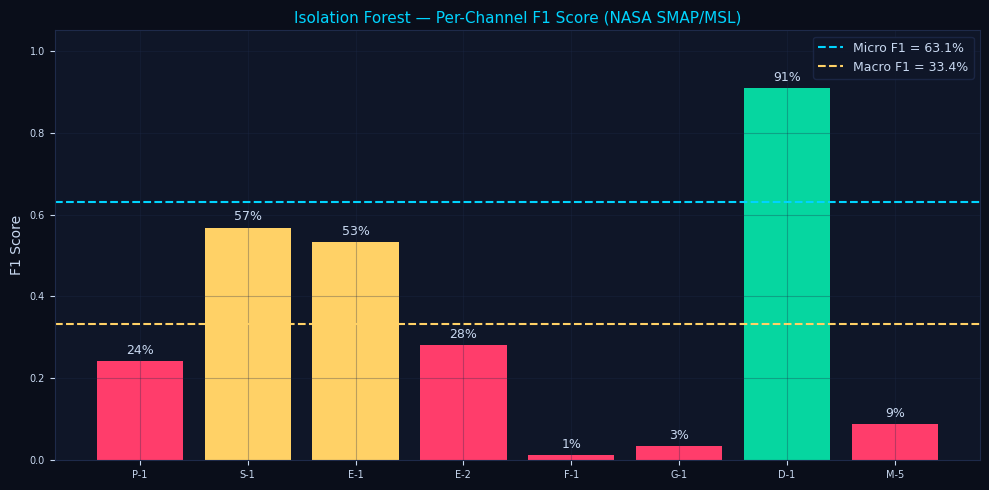

In [12]:
# Per-channel F1 bar chart
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax)

channels = list(results.keys())
f1_vals = [results[ch]['f1'] for ch in channels]
colors = [ANOMALY if f < 0.3 else '#ffd166' if f < 0.6 else '#06d6a0' for f in f1_vals]

bars = ax.bar(channels, f1_vals, color=colors, edgecolor='none')
for bar, val in zip(bars, f1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', va='bottom', fontsize=9, color=TEXT_CLR)

ax.axhline(micro_f1, color=ACCENT, ls='--', lw=1.5, label=f'Micro F1 = {micro_f1:.1%}')
ax.axhline(macro_f1, color='#ffd166', ls='--', lw=1.5, label=f'Macro F1 = {macro_f1:.1%}')
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('Isolation Forest — Per-Channel F1 Score (NASA SMAP/MSL)', fontsize=11)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR)
plt.tight_layout()
plt.show()

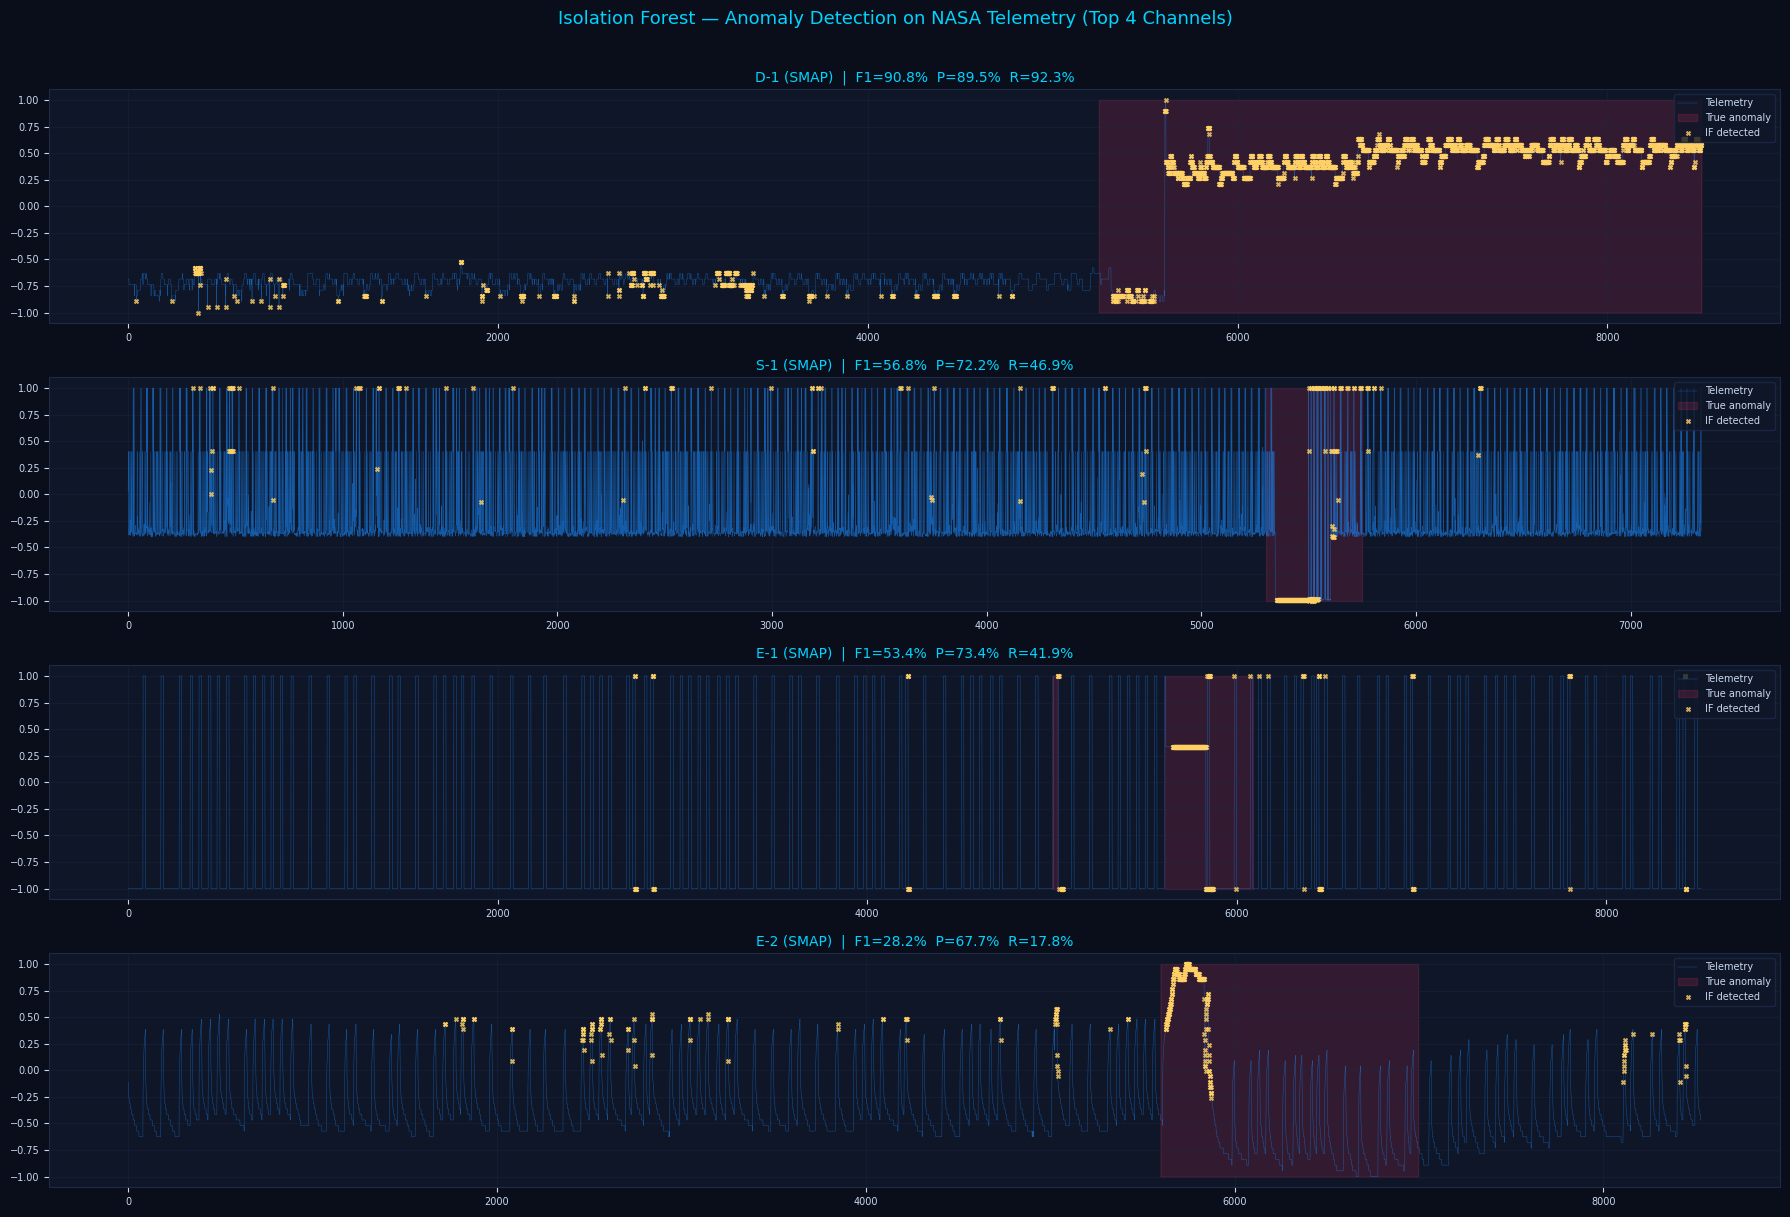

In [13]:
# Per-channel time-series plots (top 4 channels by F1)
top4 = sorted(results.keys(), key=lambda ch: results[ch]['f1'], reverse=True)[:4]

fig, axes = plt.subplots(len(top4), 1, figsize=(18, 3*len(top4)))
fig.patch.set_facecolor(DARK_BG)

for ax, ch in zip(axes, top4):
    r = results[ch]
    df = r['df_test']
    y_true = r['y_true']
    y_pred = r['y_pred']
    scores = r['test_scores']
    T = len(df)
    idx = np.arange(T)

    style_ax(ax)
    ax.plot(idx, df['val'].values, lw=0.3, color=NORMAL, alpha=0.6, label='Telemetry')

    # True anomaly regions
    anom_true = y_true == 1
    ax.fill_between(idx, df['val'].values.min(), df['val'].values.max(),
                    where=anom_true, alpha=0.15, color=ANOMALY, label='True anomaly')

    # Detected anomalies
    anom_pred = y_pred == 1
    ax.scatter(idx[anom_pred], df['val'].values[anom_pred],
               s=8, color='#ffd166', alpha=0.8, zorder=5, marker='x', label='IF detected')

    ax.set_title(f"{ch} ({r['spacecraft']})  |  F1={r['f1']:.1%}  P={r['precision']:.1%}  R={r['recall']:.1%}",
                 fontsize=10, color=ACCENT)
    ax.legend(fontsize=7, facecolor=PANEL_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR, loc='upper right')

plt.suptitle('Isolation Forest — Anomaly Detection on NASA Telemetry (Top 4 Channels)',
             fontsize=13, color=ACCENT, y=1.01)
plt.tight_layout()
plt.show()

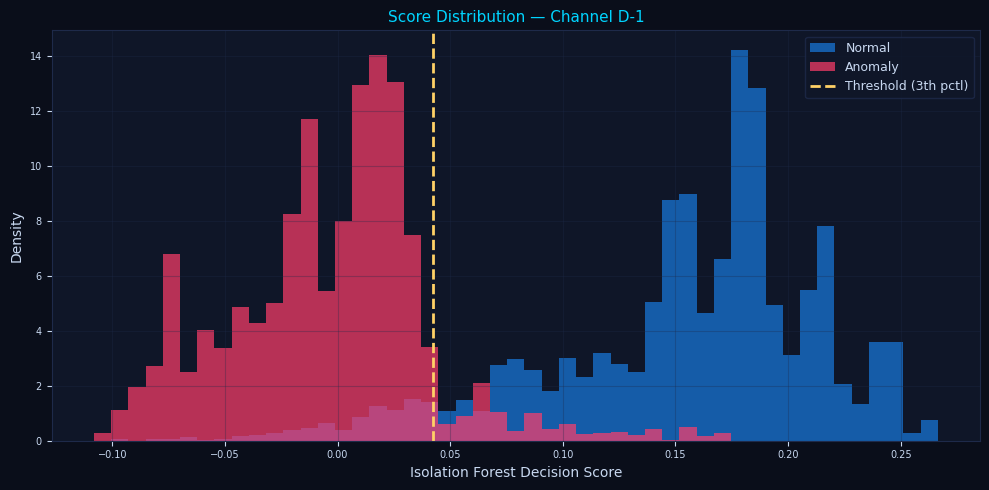

In [14]:
# Score distribution: normal vs anomaly (best channel)
best_ch = top4[0]
r = results[best_ch]
scores = r['test_scores']
y_true = r['y_true']
threshold = r['threshold']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax)

bins = np.linspace(scores.min(), scores.max(), 50)
ax.hist(scores[y_true == 0], bins=bins, color=NORMAL, alpha=0.6, label='Normal', density=True)
ax.hist(scores[y_true == 1], bins=bins, color=ANOMALY, alpha=0.7, label='Anomaly', density=True)
ax.axvline(threshold, color='#ffd166', ls='--', lw=2, label=f'Threshold ({SCORE_THRESHOLD_PCT}th pctl)')
ax.set_xlabel('Isolation Forest Decision Score')
ax.set_ylabel('Density')
ax.set_title(f'Score Distribution — Channel {best_ch}', fontsize=11, color=ACCENT)
ax.legend(fontsize=9, facecolor=PANEL_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR)
plt.tight_layout()
plt.show()

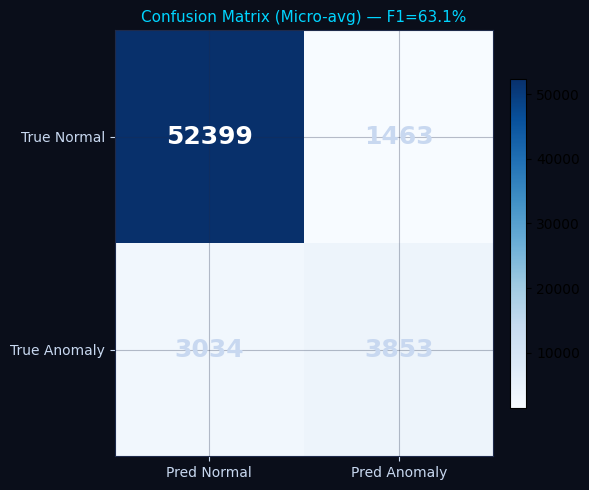

In [15]:
# Confusion matrix (micro-averaged)
cm = np.array([[tn_all, fp_all], [fn_all, tp_all]])

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax)

im = ax.imshow(cm, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > cm.max() / 2 else TEXT_CLR)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Normal', 'Pred Anomaly'], fontsize=10, color=TEXT_CLR)
ax.set_yticklabels(['True Normal', 'True Anomaly'], fontsize=10, color=TEXT_CLR)
ax.set_title(f'Confusion Matrix (Micro-avg) — F1={micro_f1:.1%}', fontsize=11, color=ACCENT)
fig.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
plt.tight_layout()
plt.show()

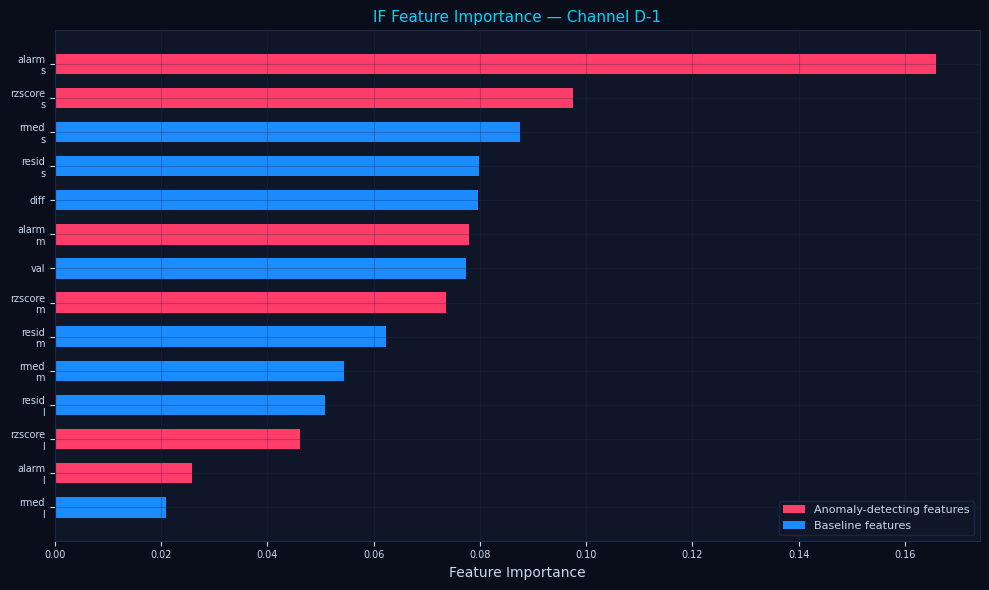

In [16]:
# Feature importance analysis (best channel)
r = results[top4[0]]
model = r['model']
feat_names = r['feature_cols']

# IF feature importance via tree inspection
importances = np.zeros(len(feat_names))
for tree in model.estimators_:
    importances += tree.feature_importances_
importances /= len(model.estimators_)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax)

order = np.argsort(importances)
top_n = min(15, len(feat_names))
top_idx = order[-top_n:]
labels = [feat_names[i].replace('_', '\n') for i in top_idx]
colors = [ANOMALY if 'rzscore' in feat_names[i] or 'alarm' in feat_names[i] else NORMAL
          for i in top_idx]

ax.barh(labels, importances[top_idx], color=colors, edgecolor='none', height=0.6)
ax.set_xlabel('Feature Importance')
ax.set_title(f'IF Feature Importance — Channel {top4[0]}', fontsize=11, color=ACCENT)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ANOMALY, label='Anomaly-detecting features'),
                   Patch(facecolor=NORMAL, label='Baseline features')]
ax.legend(handles=legend_elements, fontsize=8, facecolor=PANEL_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR)
plt.tight_layout()
plt.show()

---
## 7. Threshold Sensitivity Analysis

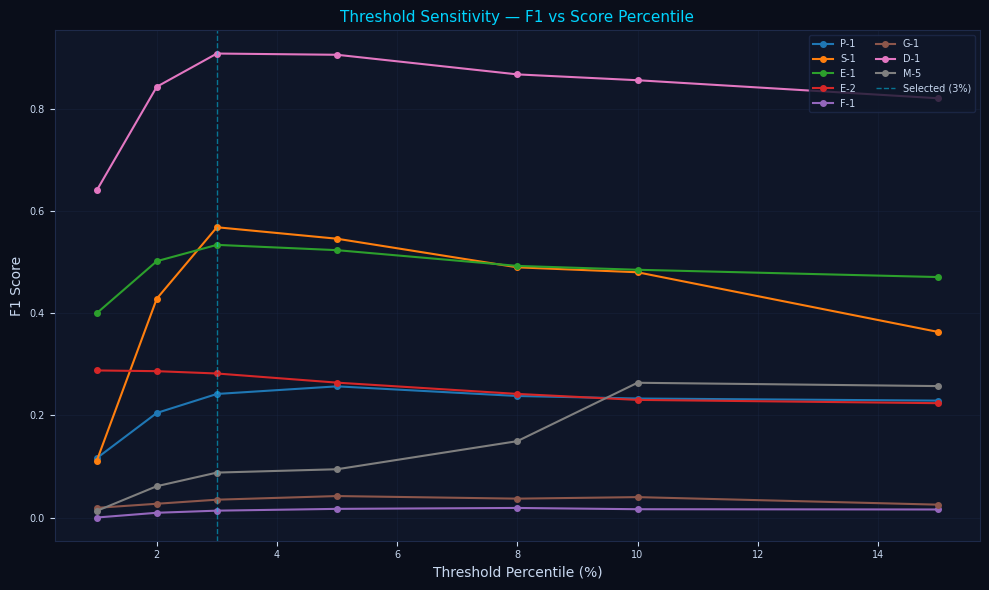

In [17]:
thresholds_to_test = [1, 2, 3, 5, 8, 10, 15]
sensitivity = {ch: [] for ch in EVAL_CHANNELS}

for pct in thresholds_to_test:
    for ch in EVAL_CHANNELS:
        r = run_channel(ch, labels_df, threshold_pct=pct)
        sensitivity[ch].append({'pct': pct, 'f1': r['f1'], 'prec': r['precision'], 'rec': r['recall']})

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(DARK_BG)
style_ax(ax)

for ch in EVAL_CHANNELS:
    pcts = [x['pct'] for x in sensitivity[ch]]
    f1s   = [x['f1'] for x in sensitivity[ch]]
    ax.plot(pcts, f1s, marker='o', ms=4, lw=1.5, label=ch)

ax.axvline(SCORE_THRESHOLD_PCT, color=ACCENT, ls='--', lw=1, alpha=0.5, label=f'Selected ({SCORE_THRESHOLD_PCT}%)')
ax.set_xlabel('Threshold Percentile (%)')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold Sensitivity — F1 vs Score Percentile', fontsize=11, color=ACCENT)
ax.legend(fontsize=7, ncol=2, facecolor=PANEL_BG, edgecolor=GRID_CLR, labelcolor=TEXT_CLR)
plt.tight_layout()
plt.show()

---
## 8. Summary & Export

In [18]:
summary = {
    'method': 'Isolation Forest',
    'dataset': 'NASA SMAP/MSL',
    'channels': len(results),
    'micro_precision': round(micro_p, 4),
    'micro_recall':    round(micro_r, 4),
    'micro_f1':        round(micro_f1, 4),
    'macro_f1':        round(macro_f1, 4),
    'confusion_matrix': [[tn_all, fp_all], [fn_all, tp_all]],
    'per_channel': {ch: {
        'f1': round(r['f1'], 4),
        'precision': round(r['precision'], 4),
        'recall': round(r['recall'], 4),
        'anomaly_rate': round(r['anomaly_rate'], 4),
    } for ch, r in results.items()},
    'hyperparams': {
        'n_estimators': 300,
        'contamination': 0.01,
        'max_features': 1.0,
        'score_threshold_pct': SCORE_THRESHOLD_PCT,
        'rolling_windows': [50, 300, 1500],
        'alarm_window': 30,
        'rzscore_clip': 30,
        'context_window': CONTEXT_WINDOW,
    },
}

os.makedirs('reports', exist_ok=True)
with open('reports/if_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print('Results saved to reports/if_metrics.json')
print()
print(json.dumps(summary, indent=2, ensure_ascii=False))

Results saved to reports/if_metrics.json

{
  "method": "Isolation Forest",
  "dataset": "NASA SMAP/MSL",
  "channels": 8,
  "micro_precision": 0.7248,
  "micro_recall": 0.5595,
  "micro_f1": 0.6315,
  "macro_f1": 0.3339,
  "confusion_matrix": [
    [
      52399,
      1463
    ],
    [
      3034,
      3853
    ]
  ],
  "per_channel": {
    "P-1": {
      "f1": 0.2419,
      "precision": 0.3067,
      "recall": 0.1997,
      "anomaly_rate": 0.0883
    },
    "S-1": {
      "f1": 0.5683,
      "precision": 0.7216,
      "recall": 0.4688,
      "anomaly_rate": 0.0611
    },
    "E-1": {
      "f1": 0.5338,
      "precision": 0.7345,
      "recall": 0.4193,
      "anomaly_rate": 0.0597
    },
    "E-2": {
      "f1": 0.282,
      "precision": 0.6766,
      "recall": 0.1781,
      "anomaly_rate": 0.1639
    },
    "F-1": {
      "f1": 0.0134,
      "precision": 0.0102,
      "recall": 0.0198,
      "anomaly_rate": 0.0118
    },
    "G-1": {
      "f1": 0.0349,
      "precision": 0.025,
